In [1]:
print("Hello Jupyter")

Hello Jupyter


# Baseball Case Study – Predicting Team Wins

**Goal:** Using 2014 Major League Baseball team statistics, build a machine learning model that predicts the number of wins (W) for a team.

This is a **regression** problem because the target (W) is a number.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
url = "https://raw.githubusercontent.com/dsrscientist/Data-Science-ML-Capstone-Projects/master/baseball.csv"
df = pd.read_csv(url)
df.head()

,W,R,AB,H,2B,3B,HR,BB,SO,SB,RA,ER,ERA,CG,SHO,SV,E
0,95,724,5575,1497,300,42,139,383,973,104,641,601,3.73,2,8,56,88
1,83,696,5467,1349,277,44,156,439,1264,70,700,653,4.07,2,12,45,86
2,81,669,5439,1395,303,29,141,533,1157,86,640,584,3.67,11,10,38,79
3,76,622,5533,1381,260,27,136,404,1231,68,701,643,3.98,7,9,37,101
4,74,689,5605,1515,289,49,151,455,1259,83,803,746,4.64,7,12,35,86


**Observation:** The dataset loaded successfully. It has team statistics where `W` (Wins) is the target variable and the remaining 16 columns are input features.

## Step 2: Understanding the Data

In [4]:
df.shape

(30, 17)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   W       30 non-null     int64  
 1   R       30 non-null     int64  
 2   AB      30 non-null     int64  
 3   H       30 non-null     int64  
 4   2B      30 non-null     int64  
 5   3B      30 non-null     int64  
 6   HR      30 non-null     int64  
 7   BB      30 non-null     int64  
 8   SO      30 non-null     int64  
 9   SB      30 non-null     int64  
 10  RA      30 non-null     int64  
 11  ER      30 non-null     int64  
 12  ERA     30 non-null     float64
 13  CG      30 non-null     int64  
 14  SHO     30 non-null     int64  
 15  SV      30 non-null     int64  
 16  E       30 non-null     int64  
dtypes: float64(1), int64(16)
memory usage: 4.1 KB


In [6]:
df.isnull().sum()

W      0
R      0
AB     0
H      0
2B     0
3B     0
HR     0
BB     0
SO     0
SB     0
RA     0
ER     0
ERA    0
CG     0
SHO    0
SV     0
E      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
W,30.0,80.966667,10.453455,63.00,74.0000,81.000,87.75,100.00
R,30.0,688.233333,58.761754,573.00,651.2500,689.000,718.25,891.00
AB,30.0,5516.266667,70.467372,5385.00,5464.0000,5510.000,5570.00,5649.00
H,30.0,1403.533333,57.140923,1324.00,1363.0000,1382.500,1451.50,1515.00
2B,30.0,274.733333,18.095405,236.00,262.2500,275.500,288.75,308.00
3B,30.0,31.300000,10.452355,13.00,23.0000,31.000,39.00,49.00
HR,30.0,163.633333,31.823309,100.00,140.2500,158.500,177.00,232.00
BB,30.0,469.100000,57.053725,375.00,428.2500,473.000,501.25,570.00
SO,30.0,1248.200000,103.759470,973.00,1157.5000,1261.500,1311.50,1518.00
SB,30.0,83.500000,22.815225,44.00,69.0000,83.500,96.50,134.00


In [9]:
df.skew()

W      0.047089
R      1.200786
AB     0.183437
H      0.670254
2B    -0.230650
3B     0.129502
HR     0.516441
BB     0.158498
SO    -0.156065
SB     0.479893
RA     0.045734
ER     0.058710
ERA    0.053331
CG     0.736845
SHO    0.565790
SV     0.657524
E      0.890132
dtype: float64

### Column descriptions
**Target:** W – Wins

**Batting (offence – higher is usually better):**
- R – Runs scored
- AB – At bats
- H – Hits
- 2B – Doubles
- 3B – Triples
- HR – Home runs
- BB – Walks (base on balls)
- SO – Strikeouts (by batters)
- SB – Stolen bases

**Pitching (defence – lower RA/ER/ERA is better):**
- RA – Runs allowed
- ER – Earned runs
- ERA – Earned run average
- CG – Complete games
- SHO – Shutouts
- SV – Saves

**Fielding:**
- E – Errors (lower is better)

### Observations from Step 2
1. The dataset has 30 rows and 17 columns – a very small dataset.
2. All columns are numeric (ERA is float, the rest are int) – no encoding needed.
3. No missing values and no duplicate rows.
4. The target W ranges from 63 to 100 wins, with a mean of ~81, and is not skewed.
5. R, CG, SHO, SV and E show a large gap between the 75% value and max → possible outliers.
6. R, E, CG, H, SV, SHO and HR have skewness above 0.5 → will be treated in Step 4.

## Step 3: Exploratory Data Analysis (EDA)

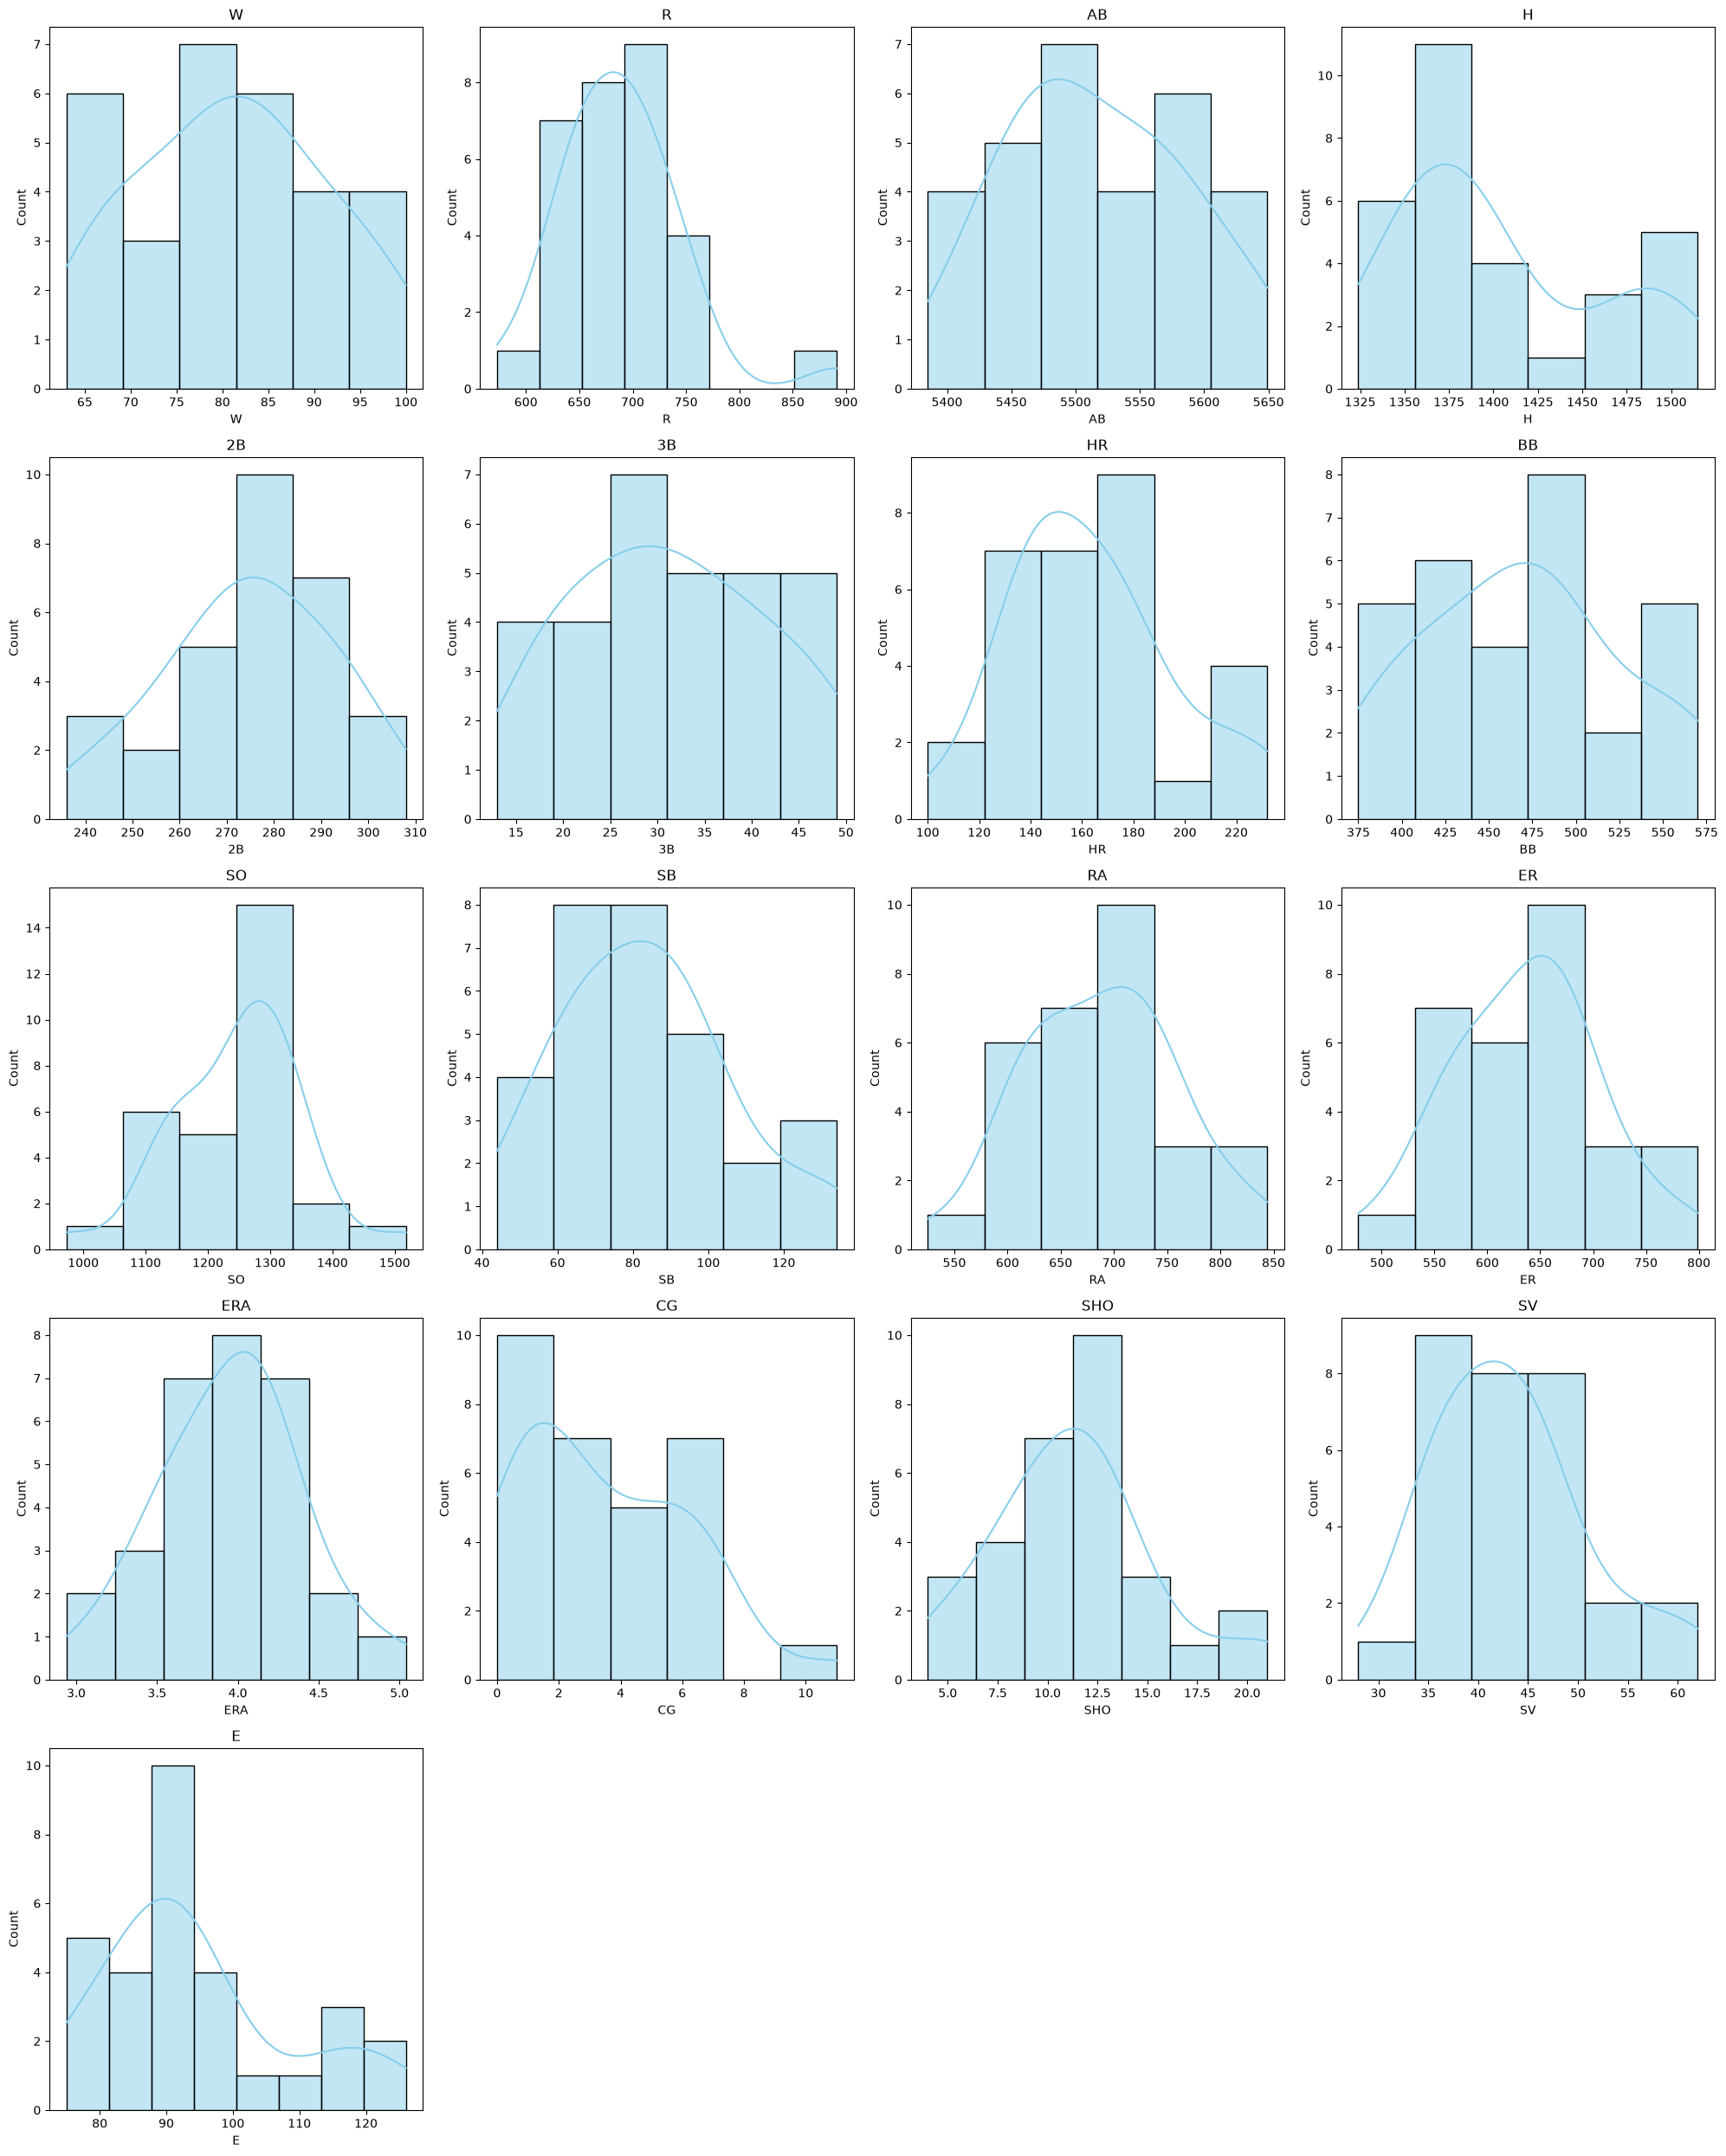

In [10]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(df.columns, 1):
    plt.subplot(5, 4, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

**Observation:** Most features are roughly normally distributed. R, E, CG, SV and SHO are right-skewed (long tail on the right).

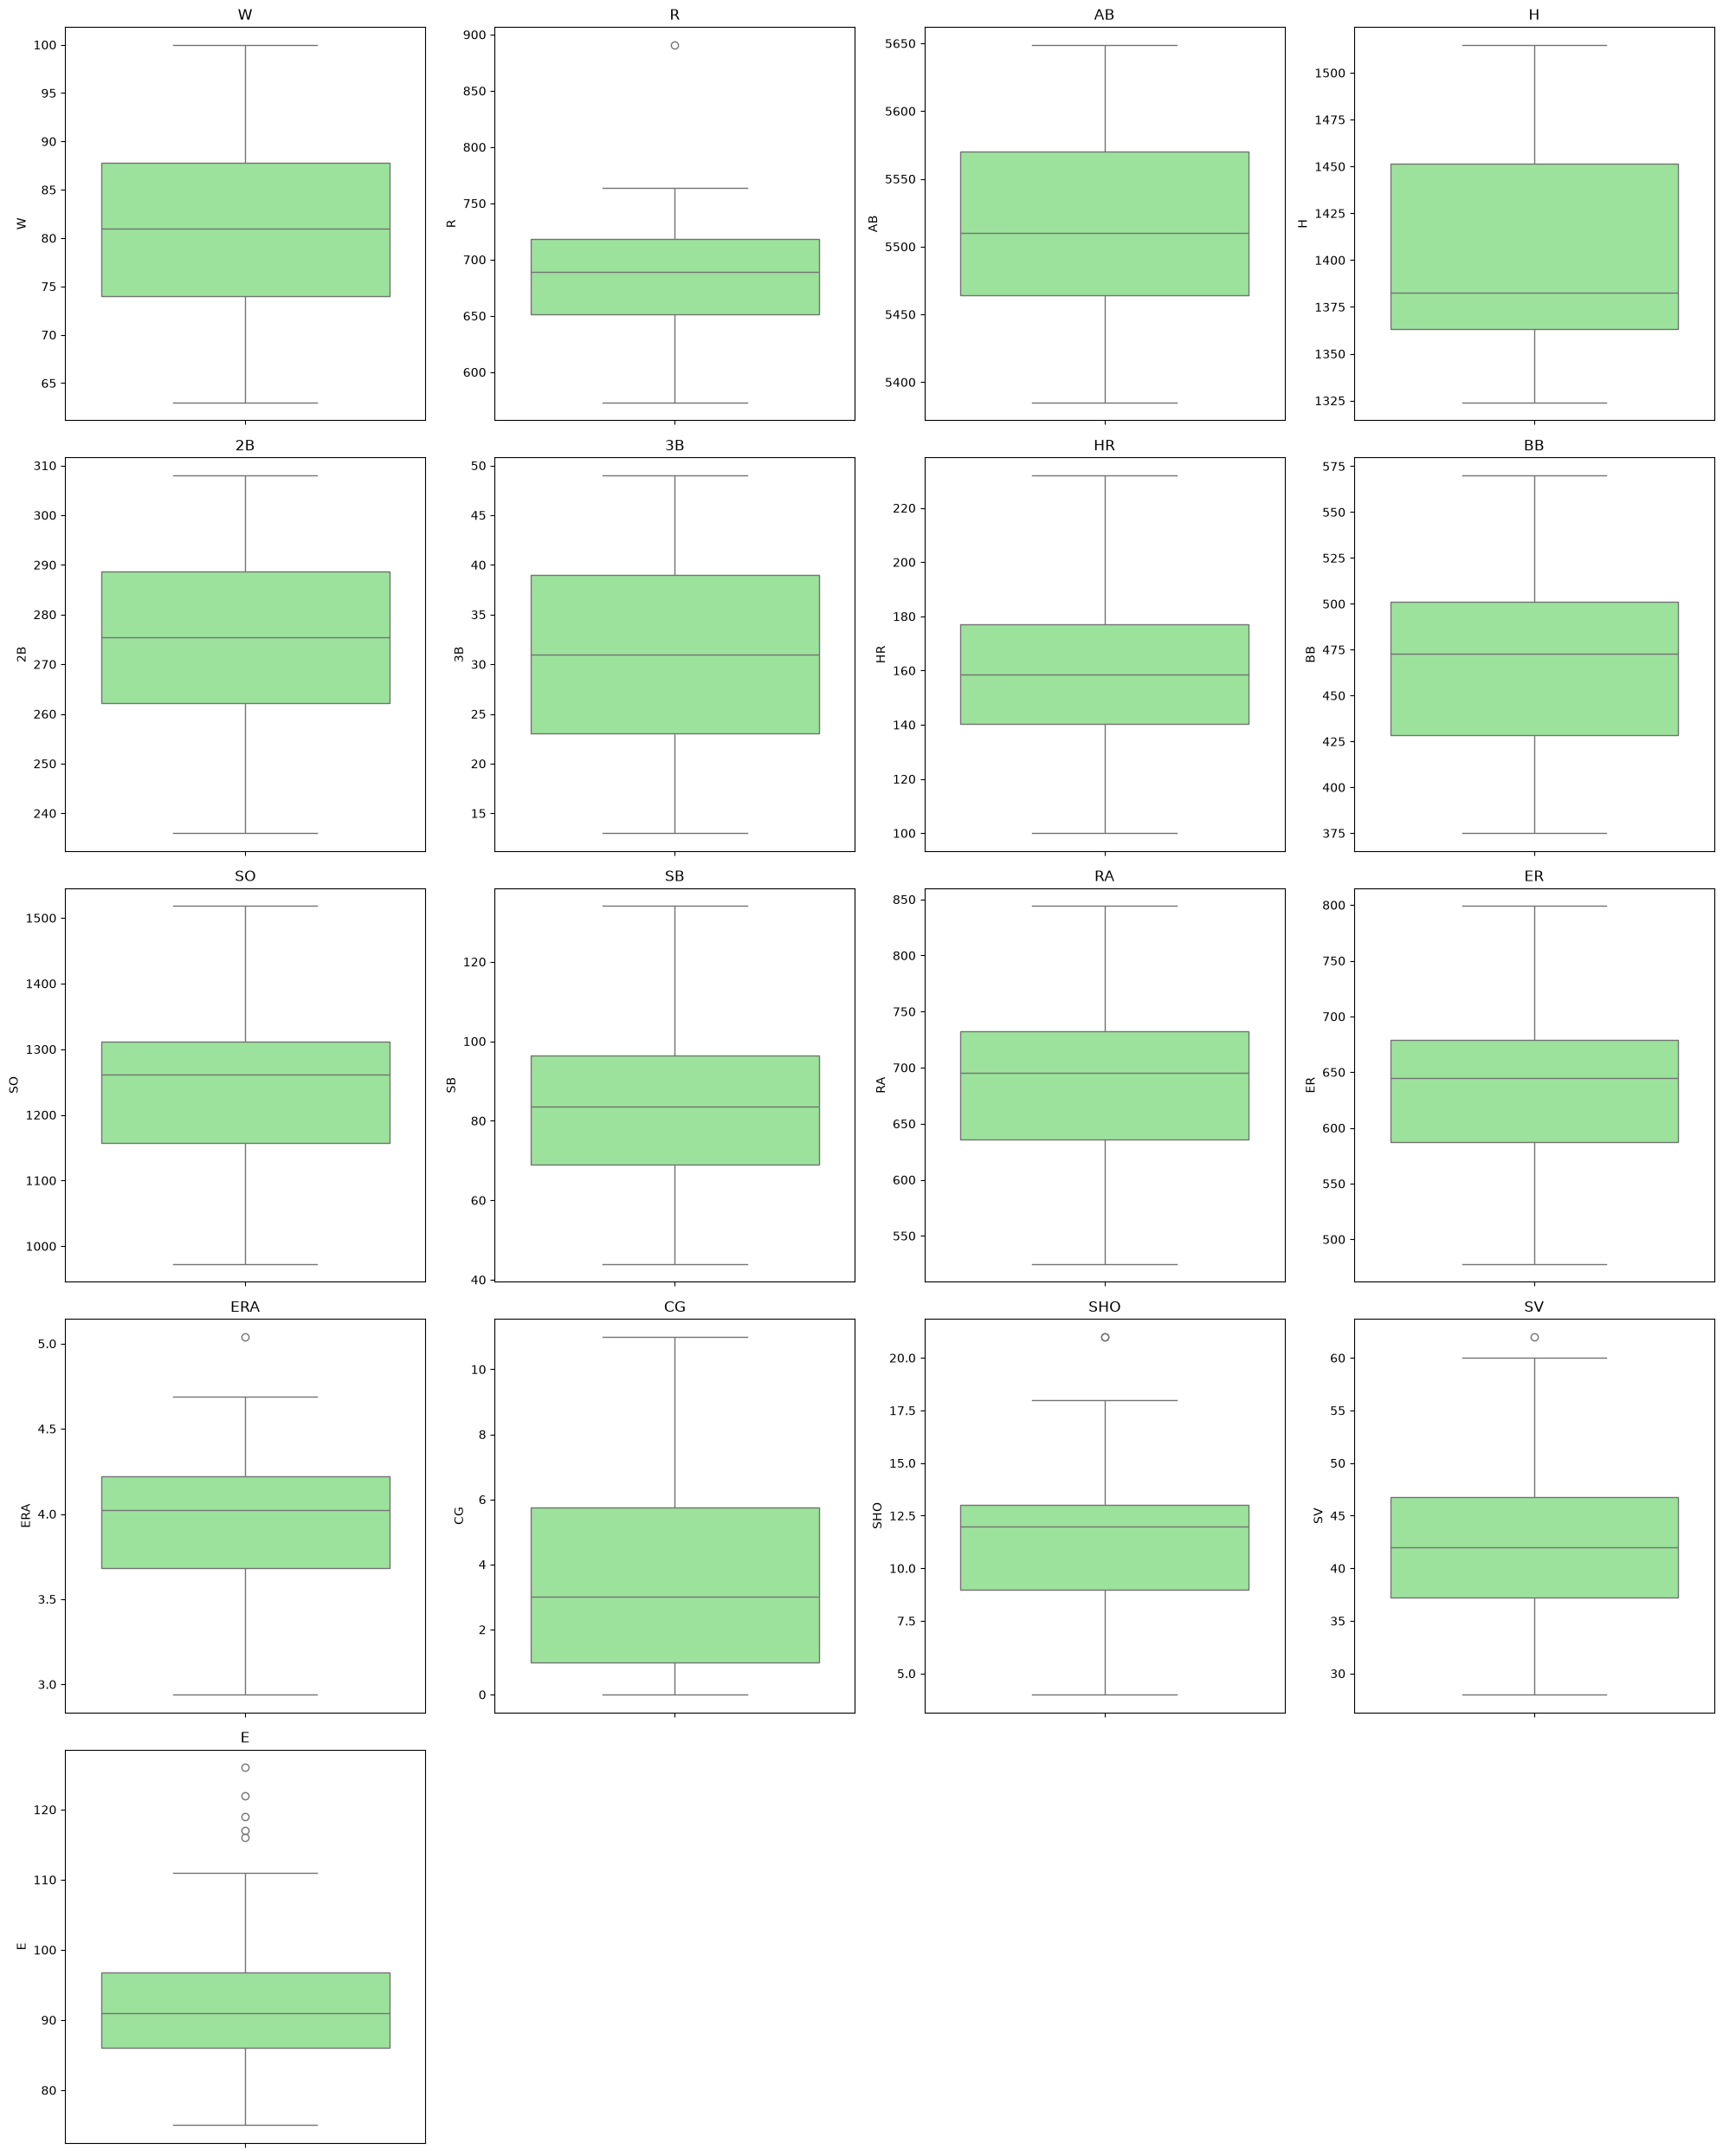

In [11]:
plt.figure(figsize=(20, 25))
for i, col in enumerate(df.columns, 1):
    plt.subplot(5, 4, i)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(col)
plt.tight_layout()
plt.show()

**Observation:** Boxplots show outliers in R, ERA, SHO, SV and E. E has the most (5). These will be treated in Step 4.

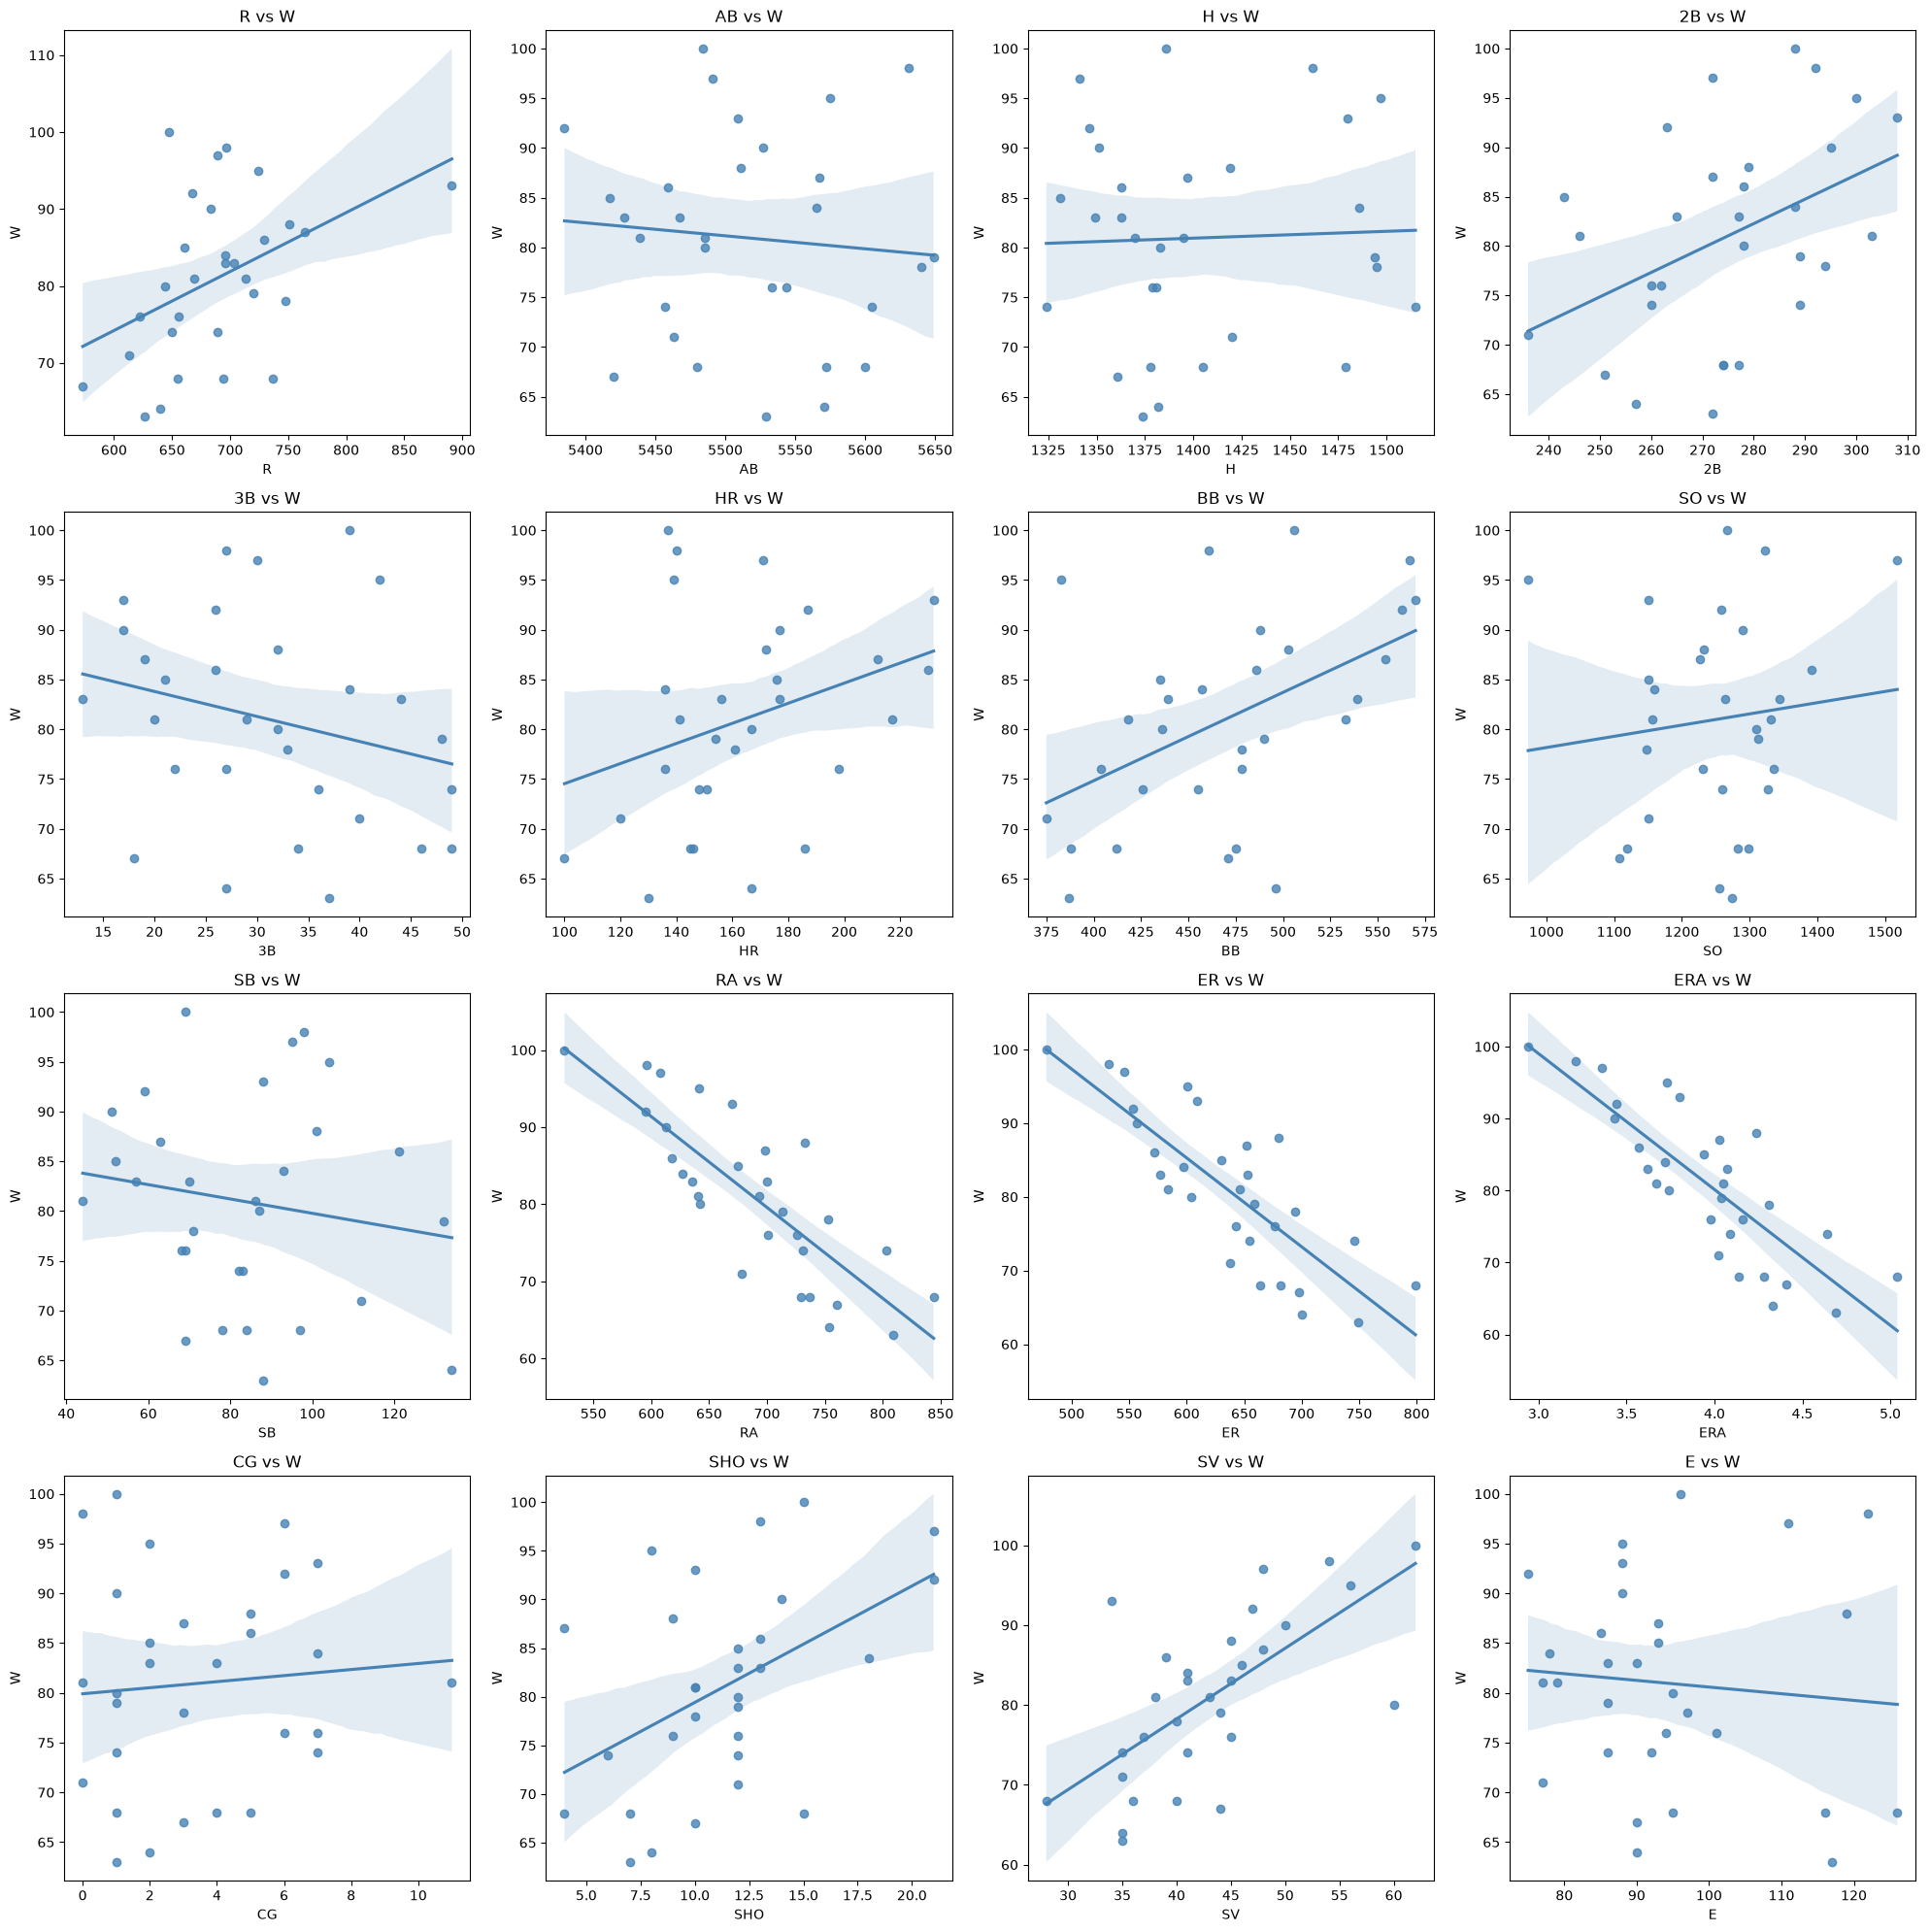

In [12]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(df.columns.drop('W'), 1):
    plt.subplot(4, 4, i)
    sns.regplot(x=df[col], y=df['W'], color='steelblue')
    plt.title(f'{col} vs W')
plt.tight_layout()
plt.show()

**Observation:** ERA, RA and ER have a strong negative relationship with Wins (good pitching = more wins). SV, BB, SHO and R have a positive relationship. H, AB, CG and SO show little relationship.

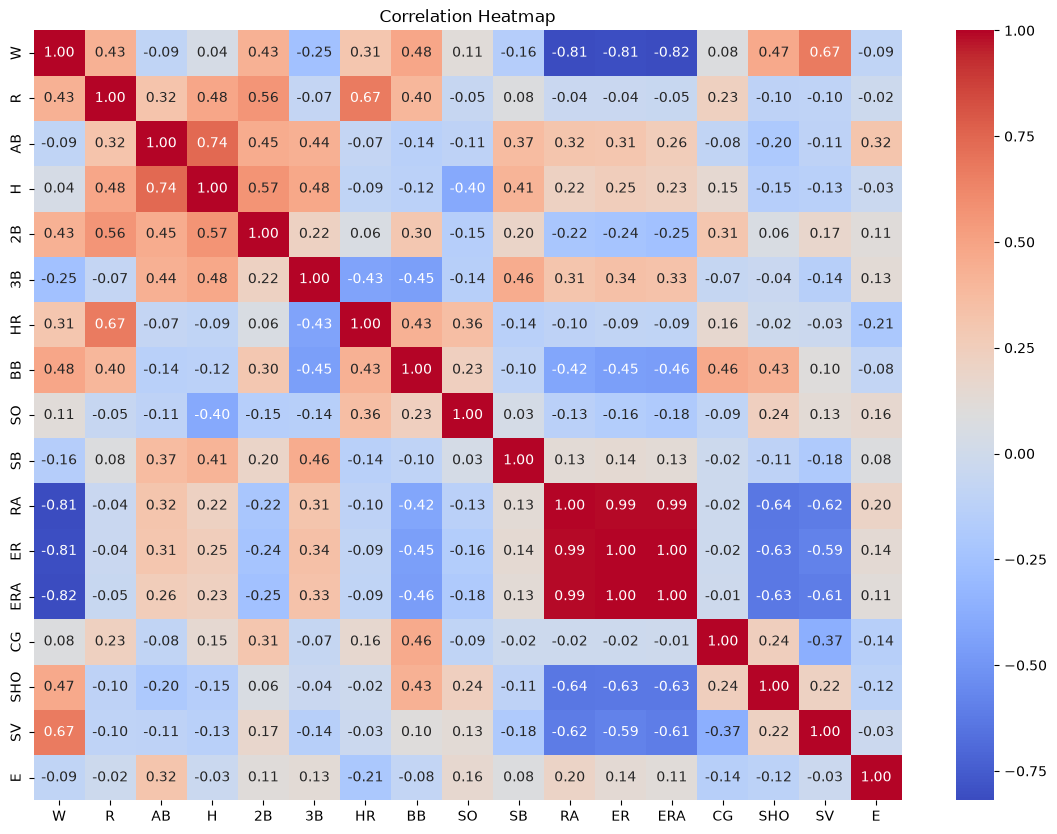

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
df.corr()['W'].sort_values(ascending=False)

W      1.000000
SV     0.666530
BB     0.484342
SHO    0.471805
R      0.430751
2B     0.427797
HR     0.307407
SO     0.111850
CG     0.080533
H      0.037612
AB    -0.087947
E     -0.089485
SB    -0.157234
3B    -0.251118
ER    -0.809435
RA    -0.812952
ERA   -0.819600
Name: W, dtype: float64

### EDA Summary
1. **Distribution:** R, E, CG, SV, SHO are right-skewed.
2. **Outliers:** Found in E (5), SHO (2), R, ERA, SV (1 each).
3. **Strongest predictors of Wins:**
   - Negative: ERA (-0.82), RA (-0.81), ER (-0.81) → good pitching/defence wins games.
   - Positive: SV (0.67), BB (0.48), SHO (0.47), R (0.43).
4. **Weak predictors:** H, AB, CG, E, SO (correlation close to 0).
5. **Multicollinearity:** RA, ER and ERA are almost perfectly correlated with each other (0.99–1.00) → will be handled in Step 5.
6. **Insight:** Pitching and defence statistics influence wins more than batting statistics.

## Step 4: Data Cleaning – Outliers and Skewness

In [15]:
from scipy.stats import zscore

z = np.abs(zscore(df))
df_z = df[(z < 3).all(axis=1)]

print("Original shape:", df.shape)
print("After Z-score :", df_z.shape)
print("Data loss %   :", (df.shape[0] - df_z.shape[0]) / df.shape[0] * 100)

Original shape: (30, 17)
After Z-score : (29, 17)
Data loss %   : 3.3333333333333335


In [16]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_iqr = df[~((df < Q1 - 1.5*IQR) | (df > Q3 + 1.5*IQR)).any(axis=1)]

print("After IQR :", df_iqr.shape)
print("Data loss %:", (df.shape[0] - df_iqr.shape[0]) / df.shape[0] * 100)

After IQR : (20, 17)
Data loss %: 33.33333333333333


In [17]:
df_new = df_z.reset_index(drop=True)
df_new.shape

(29, 17)

In [18]:
df_new.skew()

W      0.119013
R     -0.215364
AB     0.169573
H      0.783772
2B    -0.335304
3B     0.090124
HR     0.450862
BB     0.151193
SO    -0.233815
SB     0.494966
RA     0.018155
ER     0.018461
ERA    0.016693
CG     0.854980
SHO    0.526943
SV     0.627480
E      0.840271
dtype: float64

In [19]:
from sklearn.preprocessing import PowerTransformer

skewed_cols = ['CG', 'SHO', 'SV', 'E']

pt = PowerTransformer(method='yeo-johnson')
df_new[skewed_cols] = pt.fit_transform(df_new[skewed_cols])

df_new[skewed_cols].skew()

CG    -0.045947
SHO    0.000529
SV    -0.000925
E      0.065585
dtype: float64

In [20]:
df_new[skewed_cols].nunique()

CG      9
SHO    12
SV     19
E      21
dtype: int64

### Step 4 Summary
1. **Outliers:** Compared Z-score (3.33% data loss) vs IQR (33.33% loss). Chose Z-score → removed 1 row (team with 891 runs). New shape: (29, 17).
2. **Skewness re-check:** Removing the outlier fixed R's skewness (1.20 → -0.22).
3. **Skewness treatment:** Applied Yeo-Johnson PowerTransformer to CG, SHO, SV and E → skewness now near 0.
4. **H not transformed:** The transformation collapsed H to a constant value (numerical precision issue). H was left as-is since its skew is moderate and its correlation with W is ~0.
5. **Target W not transformed** – it is already normally distributed and must stay in real "wins" units.

## Step 5: Feature Selection – Multicollinearity Check (VIF)

In [21]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
X = df_new.drop('W', axis=1)
y = df_new['W']

print(X.shape, y.shape)

(29, 16) (29,)


In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

def calculate_vif(X):
    X_scaled = StandardScaler().fit_transform(X)
    vif = pd.DataFrame()
    vif['Feature'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X_scaled, i) for i in range(X.shape[1])]
    return vif.sort_values('VIF', ascending=False)

calculate_vif(X)

,Feature,VIF
10,ER,2087.230821
11,ERA,1613.845742
9,RA,199.364350
1,AB,20.237196
2,H,10.222303
5,HR,8.735387
0,R,7.163939
14,SV,5.999707
3,2B,3.529258
6,BB,3.344343


In [24]:
X = X.drop('ER', axis=1)
calculate_vif(X)

,Feature,VIF
9,RA,139.906629
10,ERA,138.879258
2,H,9.404859
1,AB,7.695530
5,HR,7.494317
0,R,6.152855
6,BB,3.343931
3,2B,3.227266
12,SHO,3.152053
4,3B,3.120866


In [25]:
X = X.drop('RA', axis=1)
calculate_vif(X)

,Feature,VIF
2,H,8.254788
5,HR,6.370966
0,R,6.139691
1,AB,5.195150
9,ERA,4.761810
3,2B,3.209869
6,BB,3.063209
4,3B,3.048408
11,SHO,3.034561
12,SV,2.574369


In [26]:
print("Final features:", list(X.columns))
print("Shape:", X.shape)

Final features: ['R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'ERA', 'CG', 'SHO', 'SV', 'E']
Shape: (29, 14)


### Step 5 Summary
1. Separated features (X, 16 columns) from target (y = W).
2. Calculated VIF to detect multicollinearity (threshold = 10).
3. ER (VIF 2087), ERA (1613) and RA (199) showed extreme multicollinearity – they are
   mathematically related (all measure runs allowed by pitchers).
4. Removed features one at a time, recalculating VIF after each removal:
   - Round 1: dropped ER → AB fell from 20.2 to 7.7 automatically.
   - Round 2: dropped RA → all VIF values now below 10.
5. Kept ERA because it has the strongest correlation with Wins (-0.83) and is a standardised rate.
6. Final dataset: 29 rows × 14 features.

## Step 6: Train-Test Split and Feature Scaling

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (23, 14)
X_test : (6, 14)
y_train: (23,)
y_test : (6,)


In [28]:
X_train[['AB', 'ERA']].describe().loc[['mean', 'std']]

,AB,ERA
mean,5518.086957,3.926957
std,72.095210,0.481904


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [30]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

X_train_scaled[['AB', 'ERA']].describe().loc[['mean', 'std']]

,AB,ERA
mean,1.672575e-15,4.368486e-16
std,1.022475e+00,1.022475e+00


In [31]:
print("Train wins avg:", y_train.mean())
print("Test wins avg :", y_test.mean())

Train wins avg: 80.69565217391305
Test wins avg : 80.0


### Step 6 Summary
1. Split the data into 80% training (23 rows) and 20% testing (6 rows) using random_state=42 for reproducibility.
2. Split was done BEFORE scaling to avoid data leakage.
3. Applied StandardScaler: fit on training data only, then transformed both train and test.
4. After scaling, training features have mean 0 and std ≈ 1 (e.g. AB went from ~5500 to ~0).
5. Target (W) was not scaled so predictions remain in real "wins" units.
6. Train and test wins averages are similar (80.7 vs 80.0) → balanced split.
7. Since the test set is very small (6 teams), cross-validation will be used in Step 8 for a more reliable evaluation.

## Step 7: Model Building and Comparison

In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [33]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(),
    'Lasso':             Lasso(),
    'KNN':               KNeighborsRegressor(),
    'SVR':               SVR(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost':          AdaBoostRegressor(random_state=42),
    'XGBoost':           XGBRegressor(random_state=42)
}

In [34]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred  = model.predict(X_test_scaled)

    results.append({
        'Model':    name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2':  r2_score(y_test, test_pred),
        'MAE':      mean_absolute_error(y_test, test_pred),
        'RMSE':     np.sqrt(mean_squared_error(y_test, test_pred))
    })

results_df = pd.DataFrame(results).sort_values('Test R2', ascending=False)
results_df.round(3)

,Model,Train R2,Test R2,MAE,RMSE
2,Lasso,0.890,0.797,3.730,4.422
0,Linear Regression,0.947,0.783,3.260,4.569
1,Ridge,0.943,0.741,4.111,4.995
9,XGBoost,1.000,0.633,5.124,5.950
6,Random Forest,0.937,0.531,6.002,6.724
7,Gradient Boosting,1.000,0.472,6.436,7.129
3,KNN,0.744,0.433,6.000,7.394
8,AdaBoost,0.987,0.429,6.762,7.420
4,SVR,0.237,0.090,8.133,9.361
5,Decision Tree,1.000,0.067,7.167,9.478


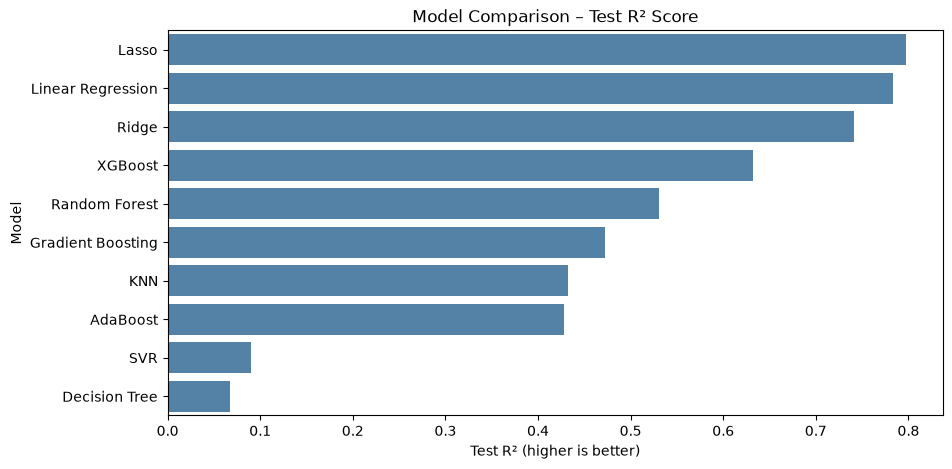

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Test R2', y='Model', color='steelblue')
plt.title('Model Comparison – Test R² Score')
plt.xlabel('Test R² (higher is better)')
plt.show()

In [36]:
lr = models['Linear Regression']
comparison = pd.DataFrame({
    'Actual Wins':    y_test.values,
    'Predicted Wins': lr.predict(X_test_scaled).round(1)
})
comparison

,Actual Wins,Predicted Wins
0,74,74.0
1,97,88.8
2,76,77.9
3,67,67.0
4,78,80.5
5,88,81.0


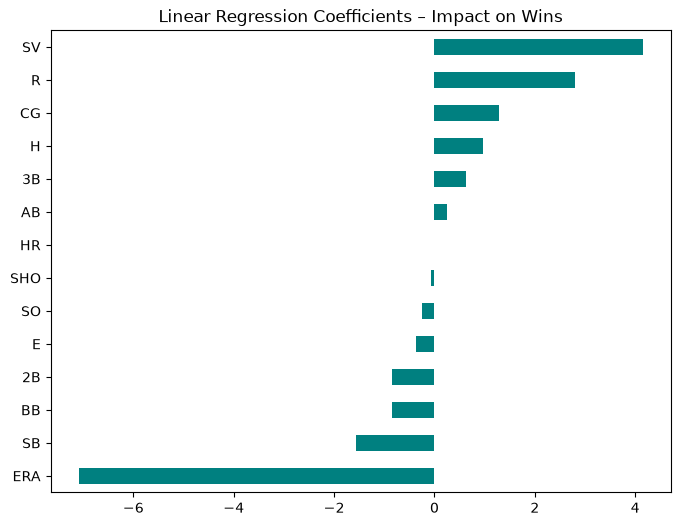

ERA   -7.084338
SB    -1.554567
BB    -0.845591
2B    -0.836939
E     -0.364733
SO    -0.255796
SHO   -0.059165
HR    -0.017541
AB     0.248694
3B     0.638619
H      0.959386
CG     1.291639
R      2.807399
SV     4.146371
dtype: float64

In [37]:
coef = pd.Series(lr.coef_, index=X.columns).sort_values()
coef.plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Linear Regression Coefficients – Impact on Wins')
plt.show()
coef

### Step 7 Summary
1. Trained and compared 10 regression models using R², MAE and RMSE.
2. Best models: Lasso (Test R² 0.80), Linear Regression (0.78, lowest MAE 3.26 wins), Ridge (0.74).
3. Linear models performed best because the key features (ERA, SV, R) have linear relationships with Wins, and simple models suit small datasets.
4. Tree-based models (Decision Tree, XGBoost, Gradient Boosting) overfit: Train R² = 1.0 but much lower Test R².
5. SVR underfit (Train R² only 0.24).
6. Linear Regression predictions were within 1–3 wins for most test teams.
7. Coefficients show ERA has the largest (negative) impact on Wins, followed by SV and R.
8. Note: the test set has only 6 teams, so these scores may be unreliable → verified with cross-validation in Step 8.

In [38]:
## Step 8: Cross-Validation

In [39]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [40]:
test_r2 = results_df.set_index('Model')['Test R2']

cv_results = []

for name, model in models.items():
    pipe = make_pipeline(StandardScaler(), model)

    scores = cross_validate(pipe, X, y, cv=kf,
                            scoring=['r2', 'neg_mean_absolute_error'])

    cv_mean = scores['test_r2'].mean()

    cv_results.append({
        'Model':      name,
        'Test R2':    test_r2[name],
        'CV R2 Mean': cv_mean,
        'CV R2 Std':  scores['test_r2'].std(),
        'CV MAE':     -scores['test_neg_mean_absolute_error'].mean(),
        'Difference': abs(test_r2[name] - cv_mean)
    })

cv_df = pd.DataFrame(cv_results).sort_values('CV R2 Mean', ascending=False)
cv_df.round(3)

,Model,Test R2,CV R2 Mean,CV R2 Std,CV MAE,Difference
2,Lasso,0.797,0.777,0.068,3.241,0.020
1,Ridge,0.741,0.635,0.101,4.444,0.106
6,Random Forest,0.531,0.401,0.194,6.069,0.129
9,XGBoost,0.633,0.399,0.270,5.533,0.234
0,Linear Regression,0.783,0.392,0.239,5.524,0.391
8,AdaBoost,0.429,0.366,0.174,6.321,0.063
3,KNN,0.433,0.364,0.213,5.732,0.068
7,Gradient Boosting,0.472,0.315,0.236,6.330,0.157
5,Decision Tree,0.067,-0.067,0.221,7.647,0.134
4,SVR,0.090,-0.312,0.533,8.203,0.402


In [41]:
cross_validate(make_pipeline(StandardScaler(), LinearRegression()), X, y, cv=kf)['test_score'].round(2)


array([0.78, 0.49, 0.38, 0.07, 0.24])

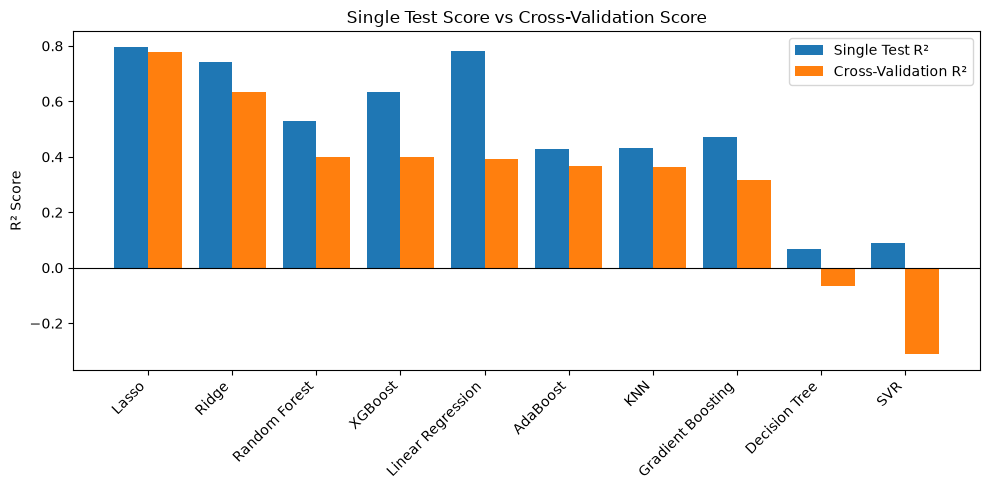

In [42]:
plt.figure(figsize=(10, 5))
x = np.arange(len(cv_df))
plt.bar(x - 0.2, cv_df['Test R2'],    width=0.4, label='Single Test R²')
plt.bar(x + 0.2, cv_df['CV R2 Mean'], width=0.4, label='Cross-Validation R²')
plt.xticks(x, cv_df['Model'], rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('R² Score')
plt.title('Single Test Score vs Cross-Validation Score')
plt.legend()
plt.tight_layout()
plt.show()

### Step 8 Summary
1. Used 5-fold cross-validation (KFold, shuffled, random_state=42) to evaluate every model on all 29 teams, since a single 6-team test set is unreliable.
2. Used a Pipeline (StandardScaler → Model) so the scaler is refitted inside each fold → no data leakage.
3. **Lasso is the best model:** CV R² 0.777, lowest std (0.068), lowest CV MAE (3.24 wins), and smallest gap between test and CV score (0.02).
4. **Linear Regression's Step 7 score was lucky:** Test R² 0.78 but CV R² only 0.39, with fold scores ranging from 0.07 to 0.78 → unstable.
5. Regularised models (Lasso, Ridge) generalise best on this small dataset because the penalty prevents fitting noise.
6. Decision Tree and SVR have negative CV R² → worse than predicting the average.
7. **Selected model: Lasso** → will be tuned in Step 9.

## Step 9: Hyperparameter Tuning (GridSearchCV)

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(max_iter=10000))
])

In [44]:
param_grid = {
    'lasso__alpha': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1, 1.5, 2, 3, 5]
}

In [45]:
grid = GridSearchCV(pipe, param_grid, cv=kf, scoring='r2')
grid.fit(X, y)

print("Best alpha   :", grid.best_params_)
print("Best CV R²   :", round(grid.best_score_, 3))

Best alpha   : {'lasso__alpha': 0.75}
Best CV R²   : 0.783


In [46]:
search_results = pd.DataFrame(grid.cv_results_)[['param_lasso__alpha', 'mean_test_score', 'std_test_score']]
search_results.columns = ['alpha', 'CV R2 Mean', 'CV R2 Std']
search_results.round(3)

,alpha,CV R2 Mean,CV R2 Std
0,0.01,0.444,0.205
1,0.05,0.571,0.117
2,0.10,0.658,0.085
3,0.20,0.715,0.095
4,0.30,0.748,0.096
5,0.50,0.773,0.087
6,0.75,0.783,0.080
7,1.00,0.777,0.068
8,1.50,0.748,0.042
9,2.00,0.699,0.031


In [47]:
from sklearn.base import clone

final_check = clone(grid.best_estimator_)
final_check.fit(X_train, y_train)
test_pred = final_check.predict(X_test)

print("Test R² :", round(r2_score(y_test, test_pred), 3))
print("Test MAE:", round(mean_absolute_error(y_test, test_pred), 3))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_pred)), 3))

pd.DataFrame({'Actual Wins': y_test.values, 'Predicted Wins': test_pred.round(1)})

Test R² : 0.794
Test MAE: 3.695
Test RMSE: 4.452


,Actual Wins,Predicted Wins
0,74,76.1
1,97,89.1
2,76,77.5
3,67,70.1
4,78,79.3
5,88,81.7


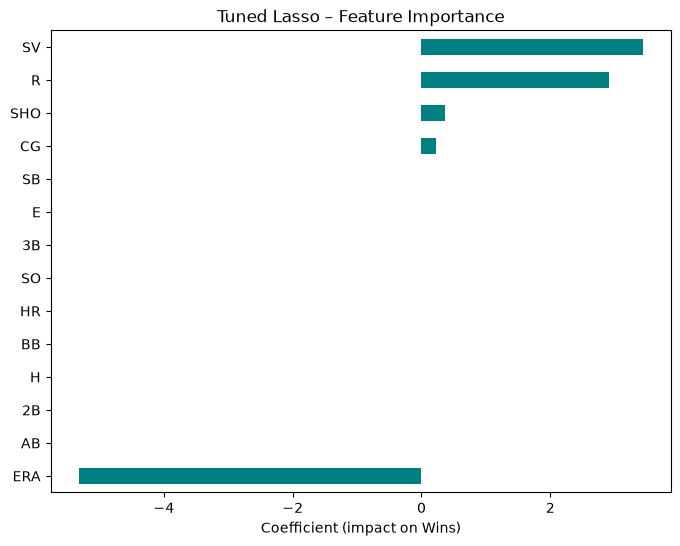

ERA   -5.32
AB    -0.00
2B     0.00
H      0.00
BB     0.00
HR     0.00
SO    -0.00
3B     0.00
E      0.00
SB    -0.00
CG     0.23
SHO    0.36
R      2.90
SV     3.43
dtype: float64

In [48]:
final_model = grid.best_estimator_
coefs = pd.Series(final_model.named_steps['lasso'].coef_, index=X.columns).sort_values()

coefs.plot(kind='barh', figsize=(8, 6), color='teal')
plt.title('Tuned Lasso – Feature Importance')
plt.xlabel('Coefficient (impact on Wins)')
plt.show()

coefs.round(2)

### Step 9 Summary
1. Tuned Lasso's `alpha` (penalty strength) using GridSearchCV with 5-fold cross-validation, testing 12 values from 0.01 to 5.
2. **Best alpha = 0.75**, CV R² = 0.783 (default alpha=1.0 gave 0.777) → small but proven improvement.
3. The alpha curve shows the overfitting/underfitting trade-off: small alpha overfits (R² 0.44), large alpha underfits (R² 0.23).
4. Tuned model on the test set: R² 0.794, MAE 3.70 wins, RMSE 4.45 → consistent with CV score, so the model is stable.
5. Lasso automatically selected 5 of 14 features: ERA, SV, R, SHO, CG.
6. **Key insight:** ERA has by far the largest impact on Wins → pitching and defence matter more than batting.

In [49]:
## Step 10: Saving the Model and Conclusion

In [50]:
import joblib

final_model = grid.best_estimator_

joblib.dump(final_model, 'baseball_model.pkl')
joblib.dump(pt, 'power_transformer.pkl')

print("Model and transformer saved!")

Model and transformer saved!


In [51]:
loaded_model = joblib.load('baseball_model.pkl')
loaded_pt    = joblib.load('power_transformer.pkl')

same = (loaded_model.predict(X) == final_model.predict(X)).all()
print("Loaded model gives identical predictions:", same)

Loaded model gives identical predictions: True


In [52]:
new_teams = pd.DataFrame([
    # Strong team: good pitching (low ERA), many saves, scores lots of runs
    {'R': 750, 'AB': 5500, 'H': 1420, '2B': 290, '3B': 30, 'HR': 180, 'BB': 500,
     'SO': 1200, 'SB': 80, 'ERA': 3.40, 'CG': 4, 'SHO': 14, 'SV': 50, 'E': 85},
    # Weak team: poor pitching (high ERA), few saves, scores fewer runs
    {'R': 620, 'AB': 5500, 'H': 1370, '2B': 260, '3B': 30, 'HR': 130, 'BB': 420,
     'SO': 1300, 'SB': 80, 'ERA': 4.60, 'CG': 1, 'SHO': 7, 'SV': 33, 'E': 110}
])

new_teams[['CG', 'SHO', 'SV', 'E']] = loaded_pt.transform(new_teams[['CG', 'SHO', 'SV', 'E']])

predictions = loaded_model.predict(new_teams)

for i, wins in enumerate(predictions, 1):
    print(f"Team {i}: predicted wins = {wins:.1f}")

Team 1: predicted wins = 95.1
Team 2: predicted wins = 63.3


## Conclusion

### Problem
Predict the number of wins (W) for a Major League Baseball team using 16 season statistics from 2014 (30 teams).

### Approach
1. **Data understanding:** 30 rows × 17 columns, all numeric, no missing values or duplicates.
2. **EDA:** Found outliers (R, ERA, SHO, SV, E), right-skewed features, and strong relationships between pitching stats and Wins.
3. **Cleaning:** Removed 1 outlier row using Z-score (3.33% data loss; IQR would have lost 33%). Treated skewness in CG, SHO, SV, E using Yeo-Johnson PowerTransformer.
4. **Feature selection:** VIF analysis revealed extreme multicollinearity between ER, RA and ERA (VIF up to 2087). Dropped ER and RA, keeping ERA → 14 features.
5. **Modelling:** Compared 10 regression models. Linear models outperformed tree-based models, which overfit the small dataset.
6. **Cross-validation:** 5-fold CV showed Linear Regression's good test score was luck (CV R² only 0.39), while **Lasso was consistently best** (CV R² 0.777, lowest variance).
7. **Tuning:** GridSearchCV found best alpha = 0.75 (CV R² 0.783).

### Final Model: Lasso Regression (alpha = 0.75)
| Metric | Score |
|---|---|
| Cross-Validation R² | 0.783 |
| Test R² | 0.794 |
| Test MAE | 3.70 wins |
| Test RMSE | 4.45 wins |

The model predicts a team's wins to within about **3–4 wins** on average.

### Key Insights
- **ERA (Earned Run Average) is the most important factor** – the lower the runs a team's pitchers allow, the more games it wins.
- **Saves (SV)** and **Runs scored (R)** are the next most important factors.
- Lasso automatically reduced 14 features to 5 (ERA, SV, R, SHO, CG).
- **Pitching and defence influence winning more than batting.**

### Limitations
- The dataset is very small (30 teams, one season), so results may vary on other seasons.
- The test set contains only 6 teams; cross-validation was used to compensate.
- Outlier removal and power transformation were fitted on the full dataset; a full pipeline could prevent this minor data leakage.

### Future Improvements
- Collect data from multiple seasons to increase sample size.
- Build a complete pipeline including the PowerTransformer.
- Try feature engineering, e.g. Run Differential (R − RA), a well-known predictor of wins.